11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Starting training...
Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9079 - loss: 0.3128 - val_accuracy: 0.9638 - val_loss: 0.1271
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9547 - loss: 0.1522 - val_accuracy: 0.9720 - val_loss: 0.0967
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9655 - loss: 0.1120 - val_accuracy: 0.9773 - val_loss: 0.0801
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9708 - loss: 0.0945 - val_accuracy: 0.9790 - val_loss: 0.0743
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9743 - loss: 0.0798 - val_accuracy: 0.9795 - val_loss: 0.0725
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9785 - loss: 0.0685 - val_accuracy: 0.9792 - val_loss: 0.0686
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9801 - loss: 0.0615 - val_accuracy: 0.9807 - val_loss: 0.0687
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9

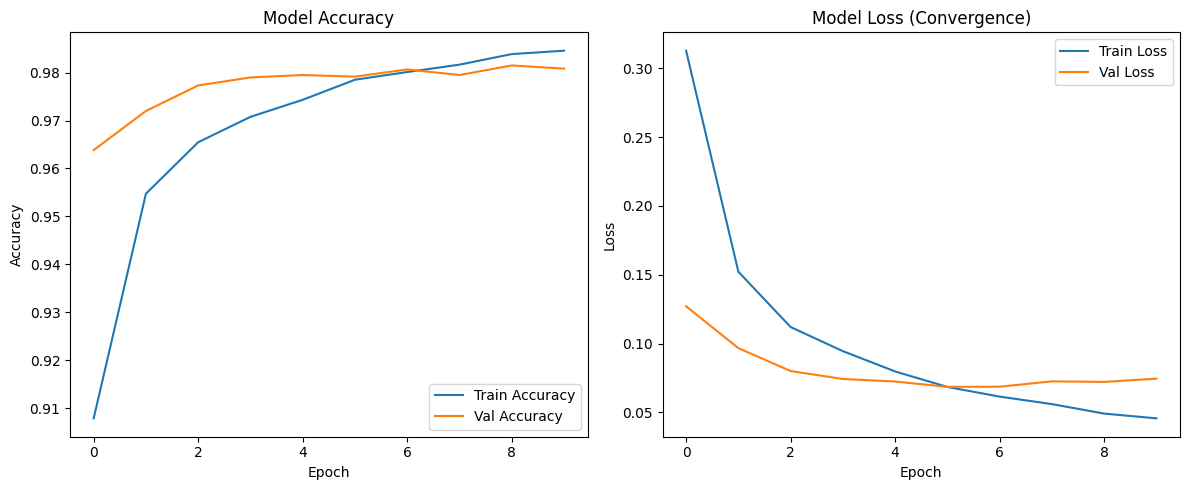

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# 1. Load the MNIST Dataset
mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# 2. Preprocess the data
# Normalize pixel values to be between 0 and 1
x_train, x_test = x_train / 255.0, x_test / 255.0

# 3. Build the Model Architecture
model = models.Sequential([
    # Flattening 28x28 images into 784-length 1D vectors
    layers.Flatten(input_shape=(28, 28)),

    # Hidden Layer: 128 neurons with ReLU activation
    layers.Dense(128, activation='relu'),

    # Dropout Layer: Randomly switches off 20% of neurons to prevent overfitting
    layers.Dropout(0.2),

    # Output Layer: 10 neurons (one per digit) with Softmax activation
    layers.Dense(10, activation='softmax')
])

# 4. Compile the Model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# 5. Train the Model
print("Starting training...")
history = model.fit(x_train, y_train, epochs=10, validation_split=0.1)

# 6. Evaluate the Model
test_loss, test_acc = model.evaluate(x_test,  y_test, verbose=2)
print(f'\nFinal Test Accuracy: {test_acc:.4f}')

# 7. Visualization of Performance
def plot_metrics(history):
    plt.figure(figsize=(12, 5))

    # Accuracy Plot
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    # Loss Plot
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title('Model Loss (Convergence)')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_metrics(history)